# Notebook 01 — C. elegans Connectome Exploration

**WiringMatters / Stage 1**

This notebook loads the real C. elegans connectome and explores its topological properties. It answers the question: *what exactly are we imposing on the neural network?*

The C. elegans hermaphrodite has **302 somatic neurons** — the canonical figure always cited in the literature. However, the connectome dataset used here (`herm_full_edgelist.csv` from OpenWorm) contains **448 unique nodes**, because it also includes 20 pharyngeal neurons and ~126 muscle and non-neuronal cells that receive chemical synapses. WiringMatters uses all 448 nodes to capture the complete wiring diagram.

---

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

import wiringmatters as wm

print(f'WiringMatters version: {wm.__version__}')

WiringMatters version: 0.1.0


## 1. Load the connectome

Data source: OpenWorm project (wormwiring.org), public CSV files.  
The first call downloads and caches the data in `~/.wiringmatters/data/`.

In [2]:
# Load chemical synapses only (the most studied type)
G, adjacency = wm.load_celegans(synapse_type='chemical', as_matrix=True)

print(f'Neurons (nodes):   {G.number_of_nodes()}')
print(f'Synapses (edges):  {G.number_of_edges()}')
print(f'Adjacency shape:   {adjacency.shape}')
print(f'Density:           {G.number_of_edges() / (G.number_of_nodes()**2):.4f}')

Neurons (nodes):   448
Synapses (edges):  4681
Adjacency shape:   (448, 448)
Density:           0.0233


## 2. Topological summary

We compute the key topological properties that distinguish the C. elegans connectome from a random or dense network.

In [3]:
summary = wm.topological_summary(G)

print('=== Topological Summary ===')
for key, value in summary.items():
    if isinstance(value, float):
        print(f'  {key:<30}: {value:.4f}')
    else:
        print(f'  {key:<30}: {value}')

=== Topological Summary ===
  n_nodes                       : 448
  n_edges                       : 4681
  density                       : 0.0234
  avg_degree                    : 20.8973
  clustering_coefficient        : 0.2946
  avg_path_length               : 2.5485
  small_world_sigma             : 0.0000
  modularity                    : 0.4512
  n_communities                 : 35
  max_degree_centrality         : 0.2349
  avg_betweenness_centrality    : 0.0023


## 3. Degree distribution

Biological networks often follow a heavy-tailed degree distribution — a few hub neurons with many connections, and most neurons with few. This is very different from a random graph.

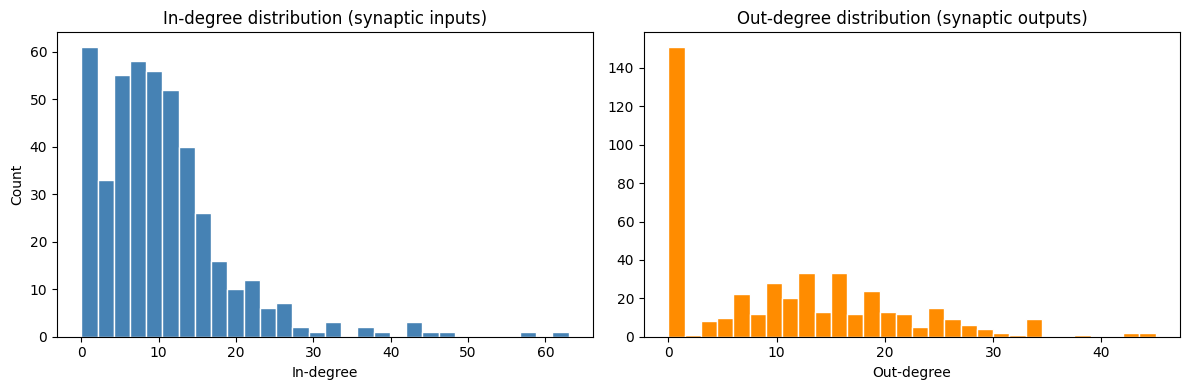

Saved: results/degree_distribution.png


In [4]:
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(in_degrees, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('In-degree distribution (synaptic inputs)')
axes[0].set_xlabel('In-degree')
axes[0].set_ylabel('Count')

axes[1].hist(out_degrees, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Out-degree distribution (synaptic outputs)')
axes[1].set_xlabel('Out-degree')

plt.tight_layout()
plt.savefig('../results/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/degree_distribution.png')

## 4. Adjacency matrix visualization

The adjacency matrix is the direct input to our mask builder. Note the block structure — this is the modularity we will later quantify.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(adjacency, cmap='Greys', aspect='auto', interpolation='nearest')
ax.set_title('C. elegans chemical synapse adjacency matrix\n(448 × 448, binary)', fontsize=13)
ax.set_xlabel('Pre-synaptic neuron')
ax.set_ylabel('Post-synaptic neuron')
plt.tight_layout()
plt.savefig('../results/adjacency_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Community structure

Louvain community detection identifies functional modules. In C. elegans, these correspond to sensory, motor, and interneuron clusters.

In [6]:
modularity_info = wm.compute_modularity(G)
print(f"Number of communities: {modularity_info['n_communities']}")
print(f"Modularity Q:          {modularity_info['modularity']:.4f}")
print()
print('Community sizes:')
for i, size in enumerate(modularity_info.get('community_sizes', [])):
    print(f'  Community {i}: {size} neurons')

Number of communities: 36
Modularity Q:          0.4529

Community sizes:
  Community 0: 95 neurons
  Community 1: 69 neurons
  Community 2: 61 neurons
  Community 3: 58 neurons
  Community 4: 57 neurons
  Community 5: 40 neurons
  Community 6: 39 neurons
  Community 7: 1 neurons
  Community 8: 1 neurons
  Community 9: 1 neurons
  Community 10: 1 neurons
  Community 11: 1 neurons
  Community 12: 1 neurons
  Community 13: 1 neurons
  Community 14: 1 neurons
  Community 15: 1 neurons
  Community 16: 1 neurons
  Community 17: 1 neurons
  Community 18: 1 neurons
  Community 19: 1 neurons
  Community 20: 1 neurons
  Community 21: 1 neurons
  Community 22: 1 neurons
  Community 23: 1 neurons
  Community 24: 1 neurons
  Community 25: 1 neurons
  Community 26: 1 neurons
  Community 27: 1 neurons
  Community 28: 1 neurons
  Community 29: 1 neurons
  Community 30: 1 neurons
  Community 31: 1 neurons
  Community 32: 1 neurons
  Community 33: 1 neurons
  Community 34: 1 neurons
  Community 35: 1 n

## 6. Hub neurons

Hub neurons have disproportionately high connectivity. They are important for information integration and are a key feature of small-world topology.

In [7]:
hub_scores = wm.compute_hub_scores(G)

# Top 10 neurons by betweenness centrality
betweenness = hub_scores.get('betweenness_centrality', {})
if betweenness:
    top_hubs = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
    print('Top 10 hub neurons (betweenness centrality):')
    for neuron, score in top_hubs:
        print(f'  {str(neuron):<20}  {score:.4f}')

Top 10 hub neurons (betweenness centrality):
  AVAR                  0.0527
  AVAL                  0.0451
  PVNR                  0.0256
  DVA                   0.0209
  PVCR                  0.0177
  HSNR                  0.0174
  AVER                  0.0163
  AVEL                  0.0149
  PVCL                  0.0134
  VD11                  0.0133


## 7. What we impose on the network

Summary of the key features that the bio-topological mask will enforce:
- **Structural sparsity**: only ~2-3% of all possible connections are active
- **Modular organization**: neurons form distinct functional clusters
- **Hub structure**: a few highly-connected neurons, many sparse ones
- **Small-world topology**: short average path lengths despite sparse global connections

None of these properties are present in a dense or uniformly sparse baseline.

In [8]:
print('=== What the Bio Mask Imposes ===')
print(f'  Sparsity:           {1 - summary["density"]:.1%} of connections are removed')
print(f'  Communities:        {summary["n_communities"]} functional modules')
print(f'  Modularity Q:       {summary["modularity"]:.3f} (0=random, 1=perfectly modular)')
print(f'  Clustering:         {summary["clustering_coefficient"]:.3f} (local density)')
print()
print('This topology is fixed and never updated during training.')
print('Only the weights W are trained, via standard backpropagation.')
print('Effective weights at each layer: W * M (elementwise product)')

=== What the Bio Mask Imposes ===
  Sparsity:           97.7% of connections are removed
  Communities:        35 functional modules
  Modularity Q:       0.451 (0=random, 1=perfectly modular)
  Clustering:         0.295 (local density)

This topology is fixed and never updated during training.
Only the weights W are trained, via standard backpropagation.
Effective weights at each layer: W * M (elementwise product)
